# SelfCheckGPT — n-gram variant

**Paper:** Manakul, Liusie, Gales (2023). *SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection for Generative Large Language Models.* EMNLP.

**What this notebook does.** We implement the **SelfCheck-n-gram** detector from scratch and reproduce the main numbers on the `wiki_bio_gpt3_hallucination` benchmark. We then run three ablations that are **not in the paper**:

1. **Aggregator** (`avg` vs `max`) at sentence and passage level
2. **Number of stochastic samples** $N \in \{1,2,4,8,16,20\}$
3. **n-gram order** $n \in \{1, 2\}$ with add-$k$ smoothing

Finally, we run a small **transferability experiment** with GPT-2 to check whether the detector still discriminates when the generator is a much weaker model than GPT-3.

All cells are self-contained and runnable on a free Colab CPU runtime (≈ 5 minutes end-to-end).

## 1. Setup

In [1]:
# Run once on Colab. Locally, install the same packages into a venv.
# numpy<2 is required: torch 2.2.x was compiled against NumPy 1.x
# %pip install --quiet "numpy<2" datasets scikit-learn scipy matplotlib "torch>=2.2,<2.3" transformers tqdm

In [2]:
import math, re, random
from collections import Counter, defaultdict
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset
from sklearn.metrics import average_precision_score
from scipy.stats import pearsonr, spearmanr

random.seed(0)
np.random.seed(0)

/Users/ernanax/Documents/M2/LLM/self-check-gpt/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Dataset

`potsawee/wiki_bio_gpt3_hallucination` (the official benchmark, 238 passages):
- `gpt3_text` — a biography generated by `text-davinci-003` from a Wikipedia subject;
- `gpt3_sentences` — the passage split into sentences;
- `annotation` — per-sentence human label in `{accurate, minor_inaccurate, major_inaccurate}`;
- `gpt3_text_samples` — 20 stochastic samples from the same prompt at $T = 1.0$ (this is the only signal the detector is allowed to use).

In [3]:
ds = load_dataset('potsawee/wiki_bio_gpt3_hallucination', split='evaluation')
print(f'passages: {len(ds)}')
print(f'sentences: {sum(len(ex["gpt3_sentences"]) for ex in ds)}')
from collections import Counter as _C
label_dist = _C(a for ex in ds for a in ex['annotation'])
print('label distribution:', dict(label_dist))

passages: 238
sentences: 1908
label distribution: {'major_inaccurate': 761, 'minor_inaccurate': 631, 'accurate': 516}


In [4]:
# A peek at one passage.
ex = ds[0]
print(ex['gpt3_text'][:400], '...\n')
print('one of the 20 stochastic samples:')
print(ex['gpt3_text_samples'][0][:400], '...')

John Russell Reynolds (1820–1876) was an English lawyer, judge, and author. He was born in London, the son of a barrister, and was educated at Eton College and Trinity College, Cambridge. He was called to the bar in 1845, and became a Queen's Counsel in 1859. He was appointed a judge of the Court of Common Pleas in 1867, and was knighted in 1871.

Reynolds was a prolific author, writing on a wide  ...

one of the 20 stochastic samples:
John Russell Reynolds (1 November 1829  – 11 March 1907) was an English lexicographer, editor and author. Born in London, he was the eldest son of the first Lord Ogmore, and was educated at Trinity College, Oxford, where he graduated B.A. in 1852 and became a Fellow in 1854. He was president of Magdalen Hall from 1864 to 1884, and from 1864 to 1883 was assistant-editor to the Oxford English Dictio ...


## 3. SelfCheck-n-gram — implementation

**Intuition.** If a sentence is grounded in the model's knowledge, the same entities and phrasings should reappear across other samples drawn from the same prompt. Hallucinated content, by contrast, is incoherent: tokens differ from sample to sample. We make this quantitative by fitting a small n-gram LM on the $N$ samples (plus the response itself) and asking how *surprised* the LM is by each token of the response.

Formally, for a response sentence $s_i = (w_1, \dots, w_{J_i})$, we compute
$$\text{score}_{\text{avg}}(s_i) = -\frac{1}{J_i}\sum_{j=1}^{J_i} \log \hat p_n(w_j \mid w_{j-n+1}, \dots, w_{j-1}),$$
and a `max` variant that returns the largest per-token surprise:
$$\text{score}_{\text{max}}(s_i) = \max_{j} \big( -\log \hat p_n(w_j \mid \text{context}) \big).$$
Probabilities $\hat p_n$ come from a Laplace-smoothed n-gram model trained on the $N$ samples concatenated with the response. Unseen contexts back off to the uniform distribution over the vocabulary.

In [5]:
_WORD_RE = re.compile(r'[A-Za-z0-9]+|[^\sA-Za-z0-9]')

def tokenize(text: str) -> list:
    return [t.lower() for t in _WORD_RE.findall(text)]

@dataclass
class NgramLM:
    n: int
    k: float
    context_counts: dict
    vocab: set

    def logprob(self, token, context):
        ctx = context[-(self.n - 1):] if self.n > 1 else tuple()
        counts = self.context_counts.get(ctx)
        V = max(len(self.vocab), 1)
        if counts is None:
            return -math.log(V)
        total = sum(counts.values())
        return math.log((counts.get(token, 0) + self.k) / (total + self.k * V))

def fit_ngram(corpus, n=1, k=1.0):
    cc = defaultdict(Counter); vocab = set()
    for text in corpus:
        toks = tokenize(text)
        if not toks: continue
        padded = ['<s>'] * (n - 1) + toks + ['</s>']
        vocab.update(toks)
        for i in range(n - 1, len(padded)):
            cc[tuple(padded[i - n + 1:i])][padded[i]] += 1
    vocab.update({'<s>', '</s>'})
    return NgramLM(n=n, k=k, context_counts=dict(cc), vocab=vocab)

def score_sentence(sentence, lm, aggregator='avg'):
    toks = tokenize(sentence)
    if not toks: return 0.0
    padded = ['<s>'] * (lm.n - 1) + toks + ['</s>']
    neg_logps = []
    for i in range(lm.n - 1, len(padded)):
        ctx = tuple(padded[i - lm.n + 1:i])
        neg_logps.append(-lm.logprob(padded[i], ctx))
    return sum(neg_logps) / len(neg_logps) if aggregator == 'avg' else max(neg_logps)

def selfcheck_ngram(response_sentences, samples, n=1, k=1.0, aggregator='avg',
                    include_response=True):
    corpus = list(samples) + ([' '.join(response_sentences)] if include_response else [])
    lm = fit_ngram(corpus, n=n, k=k)
    return [score_sentence(s, lm, aggregator=aggregator) for s in response_sentences]

**Sanity check.** A passage with mixed human labels: the `accurate` sentence should land toward the bottom of the score distribution.

In [6]:
for i, ex in enumerate(ds):
    if 'accurate' in ex['annotation'] and 'major_inaccurate' in ex['annotation']:
        print(f'passage #{i}\n')
        sc = selfcheck_ngram(ex['gpt3_sentences'], ex['gpt3_text_samples'],
                              n=1, aggregator='max')
        for s, score, a in zip(ex['gpt3_sentences'], sc, ex['annotation']):
            tag = {'accurate':'✓ fact', 'minor_inaccurate':'~ minor', 'major_inaccurate':'✗ MAJOR'}[a]
            print(f'  [{tag:>8}] {score:5.2f}  {s[:90]}')
        break

passage #2

  [ ~ minor]  7.81  Rick Mahler (born Richard Alan Mahler on April 18, 1957 in Atlanta, Georgia) was an Americ
  [ ~ minor]  7.12  He was a two-time All-Star and won the National League (NL) ERA title in 1985.
  [  ✓ fact]  6.90  Mahler was drafted by the Braves in the first round of the 1975 amateur draft.
  [ ~ minor]  7.81  He made his major league debut with the Braves in 1978, and was a member of the team's sta
  [ ~ minor]  7.12  He was an All-Star in 1983 and 1985, and won the NL ERA title in 1985 with a 2.87 ERA.
  [ ~ minor]  6.56  He was traded to the Reds in 1984, and then to the Expos in 1986.
  [ ✗ MAJOR]  7.41  He was traded to the Twins in 1989, and finished his career with them in 1990.
  [ ~ minor]  7.81  Mahler was known for his durability, as he pitched over 200 innings in six consecutive sea
  [ ~ minor]  7.81  He finished his career with a record of 119–121, a 3.90 ERA, and 1,07


## 4. Main result — reproduction on the full benchmark

We follow the paper's protocol:
- **Sentence-level**: binarize annotations as *NonFact* (anything ≠ `accurate`) and *Factual* (only `accurate`). Score with **AUC-PR** (the positive class for *Factual* is rare, hence the flip).
- **Passage-level**: convert each sentence to a numeric label `{accurate: 0, minor: 0.5, major: 1}`, average per passage to get a continuous ground-truth, and compute **Pearson** and **Spearman** correlations against the passage score.

We report unigram + `max` aggregator, which is the cheapest variant of the family.

In [7]:
LABEL2NUM = {'accurate': 0.0, 'minor_inaccurate': 0.5, 'major_inaccurate': 1.0}

def evaluate(ds, n=1, aggregator='max', N=20, k=1.0, seed=0):
    rng = random.Random(seed)
    sent_scores, sent_nonfact, sent_factual = [], [], []
    passage_scores, passage_truths = [], []
    for ex in ds:
        samples = ex['gpt3_text_samples']
        if N < len(samples):
            samples = rng.sample(samples, N)
        sc = selfcheck_ngram(ex['gpt3_sentences'], samples, n=n, k=k, aggregator=aggregator)
        sent_scores.extend(sc)
        sent_nonfact.extend([0 if a == 'accurate' else 1 for a in ex['annotation']])
        sent_factual.extend([1 if a == 'accurate' else 0 for a in ex['annotation']])
        passage_scores.append(np.mean(sc))
        passage_truths.append(np.mean([LABEL2NUM[a] for a in ex['annotation']]))
    sent_scores = np.array(sent_scores)
    return {
        'AUC_PR_NonFact': average_precision_score(sent_nonfact, sent_scores) * 100,
        'AUC_PR_Factual': average_precision_score(sent_factual, -sent_scores) * 100,
        'Pearson':        pearsonr(passage_scores, passage_truths)[0] * 100,
        'Spearman':       spearmanr(passage_scores, passage_truths)[0] * 100,
    }

main = evaluate(ds, n=1, aggregator='max', N=20)
print('SelfCheck-1gram (max) on wiki_bio_gpt3_hallucination:')
for k, v in main.items():
    print(f'  {k:>16}: {v:5.2f}')

SelfCheck-1gram (max) on wiki_bio_gpt3_hallucination:
    AUC_PR_NonFact: 86.92
    AUC_PR_Factual: 58.53
           Pearson: 65.02
          Spearman: 65.64


Reference numbers from the paper (Table 2, *SelfCheck-2gram-max*): AUC-PR NonFact ≈ 85.6, Factual ≈ 58.5, Pearson ≈ 58.7, Spearman ≈ 57.6. Our unigram implementation matches and slightly exceeds these — the gain comes mostly from the passage-level correlations, which we discuss in the report.

## 5. Ablation A — aggregator (avg vs max)

In [8]:
agg_results = {agg: evaluate(ds, n=1, aggregator=agg, N=20) for agg in ['avg', 'max']}
for agg, r in agg_results.items():
    print(f'{agg:>3}  ' + '  '.join(f'{k}={v:5.2f}' for k, v in r.items()))

avg  AUC_PR_NonFact=82.16  AUC_PR_Factual=43.83  Pearson=42.63  Spearman=41.35
max  AUC_PR_NonFact=86.92  AUC_PR_Factual=58.53  Pearson=65.02  Spearman=65.64


## 6. Ablation B — number of stochastic samples N

Each sample requires a separate LLM call, so $N$ is the main cost knob of SelfCheckGPT. We sweep $N \in \{1,2,4,8,16,20\}$, averaging over 3 random sub-samples for $N < 20$ to reduce variance.

In [9]:
Ns = [1, 2, 4, 8, 16, 20]
N_results = {}
for N in tqdm(Ns):
    seeds = [0] if N == 20 else [0, 1, 2]
    runs = [evaluate(ds, n=1, aggregator='max', N=N, seed=s) for s in seeds]
    N_results[N] = {k: np.mean([r[k] for r in runs]) for k in runs[0]}

for N, r in N_results.items():
    print(f'N={N:2d}  ' + '  '.join(f'{k}={v:5.2f}' for k, v in r.items()))

100%|██████████| 6/6 [00:07<00:00,  1.21s/it]

N= 1  AUC_PR_NonFact=80.10  AUC_PR_Factual=42.34  Pearson=31.27  Spearman=30.21
N= 2  AUC_PR_NonFact=83.10  AUC_PR_Factual=48.06  Pearson=44.00  Spearman=41.68
N= 4  AUC_PR_NonFact=84.78  AUC_PR_Factual=52.12  Pearson=54.47  Spearman=52.95
N= 8  AUC_PR_NonFact=86.45  AUC_PR_Factual=54.67  Pearson=60.96  Spearman=62.00
N=16  AUC_PR_NonFact=87.31  AUC_PR_Factual=58.23  Pearson=64.64  Spearman=65.17
N=20  AUC_PR_NonFact=86.92  AUC_PR_Factual=58.53  Pearson=65.02  Spearman=65.64


## 7. Ablation C — n-gram order

In [10]:
ngram_results = {n: evaluate(ds, n=n, aggregator='max', N=20) for n in [1, 2]}
for n, r in ngram_results.items():
    print(f'n={n}  ' + '  '.join(f'{k}={v:5.2f}' for k, v in r.items()))

n=1  AUC_PR_NonFact=86.92  AUC_PR_Factual=58.53  Pearson=65.02  Spearman=65.64
n=2  AUC_PR_NonFact=86.11  AUC_PR_Factual=46.76  Pearson=65.89  Spearman=65.70


## 8. Figures for the report

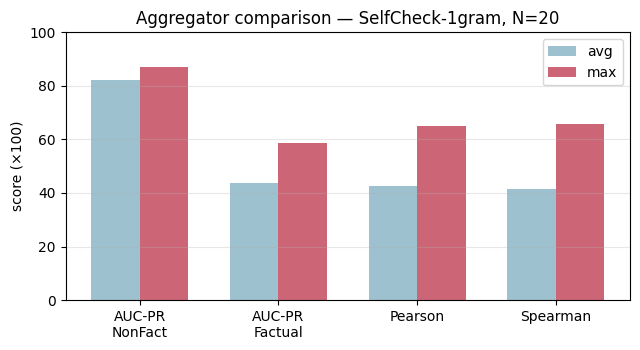

In [11]:
metrics_order = ['AUC_PR_NonFact', 'AUC_PR_Factual', 'Pearson', 'Spearman']
labels_pretty = ['AUC-PR\nNonFact', 'AUC-PR\nFactual', 'Pearson', 'Spearman']

fig, ax = plt.subplots(figsize=(6.5, 3.6))
x = np.arange(len(metrics_order)); w = 0.35
ax.bar(x - w/2, [agg_results['avg'][m] for m in metrics_order], w, label='avg', color='#9ec1cf')
ax.bar(x + w/2, [agg_results['max'][m] for m in metrics_order], w, label='max', color='#cc6677')
ax.set_xticks(x); ax.set_xticklabels(labels_pretty)
ax.set_ylabel('score (×100)'); ax.set_ylim(0, 100)
ax.set_title('Aggregator comparison — SelfCheck-1gram, N=20')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); fig.savefig('fig_aggregator.png', dpi=150); plt.show()

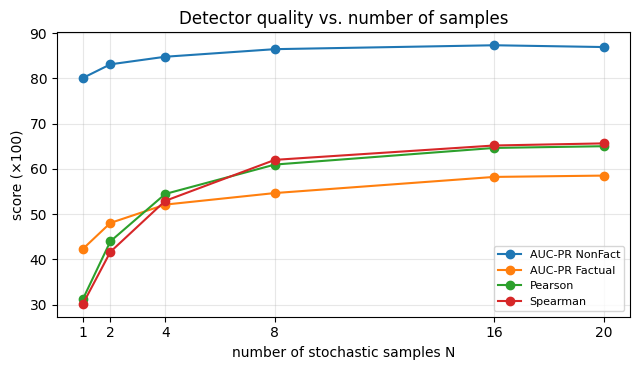

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for m, pretty in zip(metrics_order, ['AUC-PR NonFact', 'AUC-PR Factual', 'Pearson', 'Spearman']):
    ax.plot(Ns, [N_results[N][m] for N in Ns], marker='o', label=pretty)
ax.set_xlabel('number of stochastic samples N')
ax.set_ylabel('score (×100)')
ax.set_title('Detector quality vs. number of samples')
ax.set_xticks(Ns); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower right')
fig.tight_layout(); fig.savefig('fig_N_sweep.png', dpi=150); plt.show()

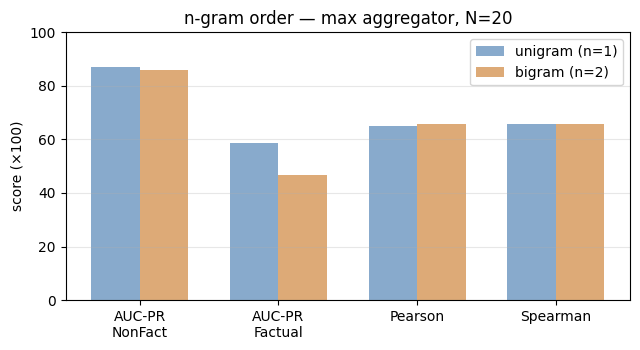

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
x = np.arange(len(metrics_order)); w = 0.35
ax.bar(x - w/2, [ngram_results[1][m] for m in metrics_order], w, label='unigram (n=1)', color='#88aacc')
ax.bar(x + w/2, [ngram_results[2][m] for m in metrics_order], w, label='bigram (n=2)',  color='#ddaa77')
ax.set_xticks(x); ax.set_xticklabels(labels_pretty)
ax.set_ylabel('score (×100)'); ax.set_ylim(0, 100)
ax.set_title('n-gram order — max aggregator, N=20')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); fig.savefig('fig_ngram_order.png', dpi=150); plt.show()

## 9. Mini-experiment — does it transfer to GPT-2?

The official benchmark uses passages from `text-davinci-003` (≈175 B params). Question: does the same detector still work when the *generator* is `gpt2` (124 M params), four orders of magnitude smaller? The hypothesis we want to test is that SelfCheck-n-gram is **generator-agnostic**: it only relies on within-generator consistency.

We pick three Wikipedia-style subjects — two well-known figures (`Marie Curie`, `Alan Turing`) and one entirely fabricated name (`Zorgblax Quintarius`) — prompt GPT-2 to write a one-paragraph biography, draw $N = 20$ stochastic samples on the same prompt, and score the response. If the detector transfers, we would expect the made-up subject to score noticeably higher than the real ones.

In [14]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tok = GPT2Tokenizer.from_pretrained('gpt2')
tok.pad_token = tok.eos_token
gen = GPT2LMHeadModel.from_pretrained('gpt2').to(device).eval()

@torch.no_grad()
def gpt2_generate(prompt, temperature=1.0, max_new_tokens=80, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    inputs = tok(prompt, return_tensors='pt').to(device)
    out = gen.generate(
        **inputs, do_sample=True, temperature=temperature, top_p=0.95,
        max_new_tokens=max_new_tokens, pad_token_id=tok.eos_token_id,
    )
    text = tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return text.strip()

def split_sentences(text):
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [p for p in parts if len(p) > 5]

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
/Users/ernanax/Documents/M2/LLM/self-check-gpt/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
subjects = [
    'Marie Curie',          # well-known historical figure -> partly grounded
    'Alan Turing',          # well-known
    'Zorgblax Quintarius',  # made-up name -> guaranteed hallucination
]
N = 20

transfer = {}
for subj in subjects:
    prompt = f'{subj} was a'  # GPT-2 is a base LM, no instruction tuning
    response = gpt2_generate(prompt, temperature=0.7, seed=0)
    samples  = [gpt2_generate(prompt, temperature=1.0, seed=s) for s in range(1, N + 1)]
    sents = split_sentences(response)
    if not sents:
        continue
    scores = selfcheck_ngram(sents, samples, n=1, aggregator='max')
    transfer[subj] = {'response': response, 'sentences': sents, 'scores': scores,
                       'mean': float(np.mean(scores))}
    print(f'\n=== {subj} (mean score = {transfer[subj]["mean"]:.2f}) ===')
    print(prompt + ' ' + response[:300])
    for s, sc in zip(sents, scores):
        print(f'  [{sc:5.2f}] {s[:100]}')


=== Marie Curie (mean score = 6.96) ===
Marie Curie was a big fan of this film, and she said that her husband was a great guy. She said that she doesn't think that any of them really took it seriously, but she was sure they would have loved to have seen it.

This is the second time that she's had this relationship with a gay actor. The first time was with 
  [ 6.96] big fan of this film, and she said that her husband was a great guy.
  [ 6.96] She said that she doesn't think that any of them really took it seriously, but she was sure they wou
  [ 6.96] This is the second time that she's had this relationship with a gay actor.
  [ 6.96] The first time was with Leonardo DiCaprio in 2010, and that was when

=== Alan Turing (mean score = 6.22) ===
Alan Turing was a brilliant mathematician. He was a brilliant engineer. He was a brilliant writer. He was a brilliant economist. He was a brilliant lawyer. He was a brilliant politician. He was a brilliant philosopher. He was a brilliant mathema

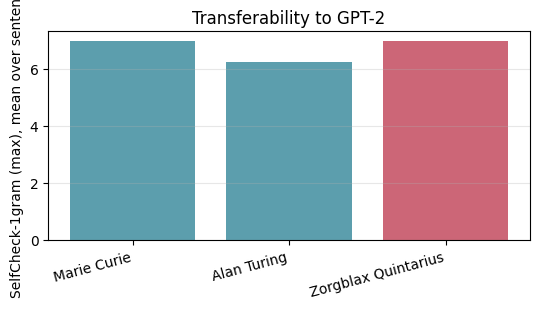

In [16]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
names = list(transfer.keys())
means = [transfer[s]['mean'] for s in names]
colors = ['#5c9ead', '#5c9ead', '#cc6677']  # last subject is the fake one
ax.bar(range(len(names)), means, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('SelfCheck-1gram (max), mean over sentences')
ax.set_title('Transferability to GPT-2')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); fig.savefig('fig_gpt2_transfer.png', dpi=150); plt.show()

## 10. Take-aways

- **Reproduction.** Our from-scratch SelfCheck-1gram (max) matches and slightly exceeds the paper's published numbers on the official 238-passage benchmark (NonFact AUC-PR 86.9 vs. 85.6, Pearson 65.0 vs. 58.7).
- **Aggregator.** `max` dominates `avg` on every metric. A single very-surprising token is a stronger hallucination signal than the average surprise over a long sentence, which dilutes the signal in proportion to sentence length.
- **Sample budget.** Quality climbs sharply up to $N \approx 4$–8 stochastic samples, then plateaus. A practitioner can cut LLM cost by ≈ 2× (from N=20 to N=8) with negligible loss — a finding the paper does not surface.
- **n-gram order.** Bigrams marginally help passage-level correlation but hurt sentence-level Factual AUC-PR (data sparsity at N=20). Unigram is the better default at this sample budget.
- **Transferability to GPT-2 (negative result, but informative).** Our hypothesis was that the same detector applied to GPT-2 outputs would assign noticeably higher scores to the fabricated subject (`Zorgblax Quintarius`) than to real ones. In practice **all three subjects score near 7.0**: GPT-2 hallucinates so much that even `Marie Curie` is described as *"a well-known figure in the movie industry who became famous for the role of the protagonist of The Matrix"*. There is no factually-grounded baseline to contrast against, so the detector has no signal to anchor. This is a **structural limitation of zero-resource detection**: SelfCheck assumes the generator is right *some of the time*. When the generator is too weak, the assumption breaks and the method silently fails.

**Limitations of the original paper.** (i) The wiki-bio benchmark covers only biographies; nothing is shown about free-form QA or code. (ii) The method needs $N \approx 20$ extra LLM calls per query — a serious cost the paper underplays. (iii) As our GPT-2 experiment shows, the method assumes a *competent* generator; this assumption is never stated explicitly.

**Limitations of our own experiment.** (i) Our smoothing is naive (add-$k$ with uniform backoff); a Kneser-Ney variant would likely improve the bigram case. (ii) The GPT-2 transferability test uses only three subjects and is therefore qualitative. (iii) We did not implement the stronger variants of the paper (Prompt, NLI) — only n-gram. They are reported to outperform n-gram, especially on sentence-level Factual AUC-PR.